# Raw vs Cluster Trajectories (same plotting code as `viz_agent.py`)

This notebook calls `viz_agent.run_plot_pipeline(...)` so plotting behavior is identical to CLI.


In [1]:
from pprint import pprint
import os

import numpy as np
import pandas as pd

from preprocess_centroids import run_dynamic_clustering_scene, build_centroid_tracks_from_clusters
from utils.data import make_motsynth_df, resolve_motsynth_root
from utils.plotting import prepare_matplotlib
from viz_agent import PlotConfig, run_plot_pipeline

# Use shared plotting backend so notebook plots match script styling (SciencePlots when installed).
plt = prepare_matplotlib(use_agg=False)


In [4]:
# ---- Configure ----
DATA_DIR = 'dataset'
START_FRAME = 75
FINISH_FRAME = 950

cfg = PlotConfig(
    direction_thresh_deg=50.0,
    distance_thresh_px=120.0,
    lof_contamination=0.2,
    lof_neighbor_ratio=0.8,
    reeval_interval=10,
    temporary_recluster_min_size=10,
    cluster_empty_tolerance=3,
    centroid_update_interval=1,
)

# 4-scene paired raw-vs-cluster settings
SCENE_IDS_4 = [
    '010', '011',
    '012', '013',
]

# Layout: 2 rows x 4 cols where each scene uses a pair of panels
# [raw | cluster] [raw | cluster]
PAIR_GRID_ROWS = 2
PAIR_GRID_COLS = 4


> Run the next cell (4-scene subplot) directly.

The old single-scene `run_plot_pipeline(...)` call was removed to avoid list-vs-string scene_id errors.


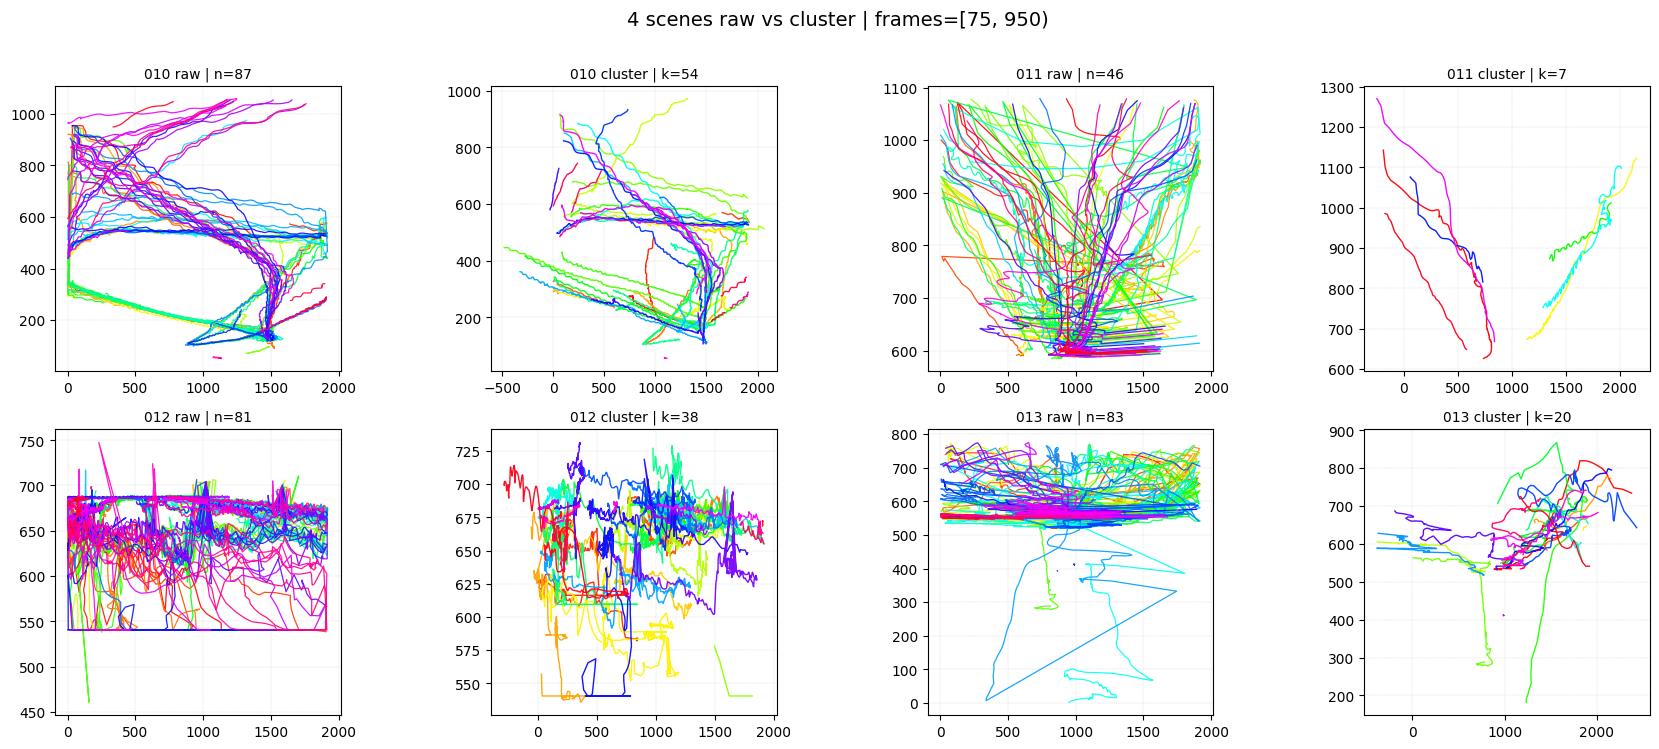

{'010': {'cluster_count': 54, 'raw_ped_count': 87},
 '011': {'cluster_count': 7, 'raw_ped_count': 46},
 '012': {'cluster_count': 38, 'raw_ped_count': 81},
 '013': {'cluster_count': 20, 'raw_ped_count': 83}}


In [5]:
# 4-scene raw-vs-cluster subplot (paired panels per scene)
assert len(SCENE_IDS_4) == 4, f"Expected 4 scene ids, got {len(SCENE_IDS_4)}"
assert PAIR_GRID_COLS % 2 == 0, "PAIR_GRID_COLS must be even (raw|cluster pairs)"
assert PAIR_GRID_ROWS * PAIR_GRID_COLS >= 2 * len(SCENE_IDS_4), "Not enough subplot slots for configured scenes"

pairs_per_row = PAIR_GRID_COLS // 2
motsynth_root = resolve_motsynth_root(DATA_DIR)

fig, axes = plt.subplots(PAIR_GRID_ROWS, PAIR_GRID_COLS, figsize=(4.4 * PAIR_GRID_COLS, 3.8 * PAIR_GRID_ROWS))
axes = np.array(axes).reshape(PAIR_GRID_ROWS, PAIR_GRID_COLS)

scene_summaries = {}

for i, scene in enumerate(SCENE_IDS_4):
    pair_row = i // pairs_per_row
    pair_col_block = i % pairs_per_row
    col_raw = 2 * pair_col_block
    col_cluster = col_raw + 1

    ax_raw = axes[pair_row, col_raw]
    ax_cluster = axes[pair_row, col_cluster]

    scene_id = f"{int(scene):03d}" if str(scene).isdigit() else str(scene)

    try:
        gt_path = os.path.join(motsynth_root, 'mot_annotations', scene_id, 'gt', 'gt.txt')
        raw = make_motsynth_df(gt_path).rename(columns={'bb_center_x': 'x', 'bb_center_y': 'y'})
        raw = raw[(raw['frame'] >= START_FRAME) & (raw['frame'] < FINISH_FRAME)].copy()

        if raw.empty:
            ax_raw.set_title(f"{scene_id} raw (empty)")
            ax_cluster.set_title(f"{scene_id} cluster (empty)")
            ax_raw.axis('off')
            ax_cluster.axis('off')
            scene_summaries[scene_id] = {'raw_ped_count': 0, 'cluster_count': 0}
            continue

        # ---- RAW PANEL ----
        raw_ids = sorted(raw['id'].astype(int).unique().tolist())
        raw_cmap = plt.cm.get_cmap('hsv', max(1, len(raw_ids)))
        for j, pid in enumerate(raw_ids):
            sub = raw[raw['id'].astype(int) == pid].sort_values('frame')
            if len(sub) >= 2:
                ax_raw.plot(sub['x'].to_numpy(), sub['y'].to_numpy(), linewidth=0.9, alpha=0.9, color=raw_cmap(j))

        ax_raw.set_title(f"{scene_id} raw | n={len(raw_ids)}", fontsize=10)
        ax_raw.grid(True, linestyle='--', linewidth=0.3, alpha=0.5)
        ax_raw.set_aspect('auto')
        ax_raw.set_box_aspect(1)

        # ---- CLUSTER PANEL ----
        frames = sorted(raw['frame'].astype(int).unique().tolist())
        ids = raw_ids
        id2i = {pid: k for k, pid in enumerate(ids)}
        frame2t = {fr: t for t, fr in enumerate(frames)}

        traj = np.zeros((len(ids), len(frames), 1, 3), dtype=np.float32)
        mask = np.zeros((len(ids), len(frames), 1), dtype=np.float32)
        for row in raw.itertuples(index=False):
            k = id2i[int(row.id)]
            t = frame2t[int(row.frame)]
            traj[k, t, 0, 0] = float(row.x)
            traj[k, t, 0, 1] = float(row.y)
            mask[k, t, 0] = 1.0

        clusters = run_dynamic_clustering_scene(
            scene_traj=traj,
            scene_mask=mask,
            frames=frames,
            direction_thresh_deg=cfg.direction_thresh_deg,
            distance_thresh_px=cfg.distance_thresh_px,
            lof_contamination=cfg.lof_contamination,
            lof_neighbor_ratio=cfg.lof_neighbor_ratio,
            reeval_interval=cfg.reeval_interval,
            temporary_recluster_min_size=cfg.temporary_recluster_min_size,
            cluster_empty_tolerance=cfg.cluster_empty_tolerance,
            centroid_update_interval=cfg.centroid_update_interval,
        )
        centroid_tracks, centroid_masks, centroid_ids, _ = build_centroid_tracks_from_clusters(clusters, frames)

        cl_cmap = plt.cm.get_cmap('hsv', max(1, len(centroid_ids)))
        for j, _cid in enumerate(centroid_ids):
            valid = np.where(centroid_masks[j] > 0)[0]
            if len(valid) >= 2:
                xy = centroid_tracks[j, valid]
                ax_cluster.plot(xy[:, 0], xy[:, 1], linewidth=1.0, alpha=0.95, color=cl_cmap(j))

        ax_cluster.set_title(f"{scene_id} cluster | k={len(centroid_ids)}", fontsize=10)
        ax_cluster.grid(True, linestyle='--', linewidth=0.3, alpha=0.5)
        ax_cluster.set_aspect('auto')
        ax_cluster.set_box_aspect(1)

        scene_summaries[scene_id] = {
            'raw_ped_count': len(raw_ids),
            'cluster_count': len(centroid_ids),
        }

    except Exception as exc:
        ax_raw.set_title(f"{scene_id} raw (error)")
        ax_cluster.set_title(f"{scene_id} cluster (error)")
        ax_raw.axis('off')
        ax_cluster.axis('off')
        scene_summaries[scene_id] = {'error': str(exc)}

# Hide extra axes if any
total_pairs = PAIR_GRID_ROWS * pairs_per_row
for idx in range(len(SCENE_IDS_4), total_pairs):
    rr = idx // pairs_per_row
    cc_block = idx % pairs_per_row
    axes[rr, 2 * cc_block].axis('off')
    axes[rr, 2 * cc_block + 1].axis('off')

fig.suptitle(f"4 scenes raw vs cluster | frames=[{START_FRAME}, {FINISH_FRAME})", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

pprint(scene_summaries)
